# Weekly Genre Prediction — Full Notebook

This notebook provides a full, modular pipeline to forecast weekly music-genre metrics
(primarily `count` of songs by genre per week and the genre's average `rank`).

It contains the following logical sections:
- Data loading and cleaning: read a CSV with a `date` column and `genre`, convert to weekly bins.
- Aggregation: produce per-(week,genre) features used for modeling (counts, average rank, etc.).
- Feature engineering: add rolling statistics and momentum features to capture trends.
- Modeling: multiple forecasting approaches — Exponential Smoothing, ARIMA, Prophet (optional),
  and a PyTorch LSTM (teacher-forcing style) for multi-step forecasts.
- Evaluation: split historic data into train / validation windows, compute RMSE, and plot results.
- Final forecasting: produce forward forecasts, compare model outputs, and save summary tables/plots.

Usage notes and tips:
- Update the `DATA_PATH` variable in the Data Loading cell to point to your input CSV file.
- The CSV must contain a `date` column (parsable by `pd.to_datetime`) and a `genre` column.
- `prophet` is optional — if not installed the notebook skips Prophet and keeps running.
- The LSTM uses PyTorch and will train on CPU by default; enable CUDA for faster training if available.
- Some cells can be slow (model fitting / LSTM training). Run individual sections interactively.

If you want, I can also: run the notebook, adjust `DATA_PATH`, or add unit-checks for key functions.


In [1]:
# --- Setup & Imports ---
# This cell centralizes imports, warning suppression, and optional dependency handling.
import os
import warnings
import logging
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Suppress noisy warnings to keep notebook output readable. Keep important errors visible.
warnings.filterwarnings("ignore")
warnings.simplefilter('ignore', ConvergenceWarning)

# Reduce logging noise from cmdstanpy/Prophet when used later (non-fatal).
logger = logging.getLogger('cmdstanpy')
logger.addHandler(logging.NullHandler())
logger.propagate = False
logger.setLevel(logging.CRITICAL)

# Standard data science libraries
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Traditional time-series models from statsmodels
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

# Prophet is optional; if unavailable we set a flag and continue without it.
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception as e:
    # Prophet is not required for the notebook to run; we log the reason.
    Prophet = None
    PROPHET_AVAILABLE = False
    print('Prophet not available:', e)

# PyTorch for the LSTM model (used only in that section). If CUDA is available it'll be used.
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Print a quick environment summary so the user knows whether GPU will be used.
print('Environment ready. Torch device:', 'cuda' if torch.cuda.is_available() else 'cpu')


Environment ready. Torch device: cuda


In [2]:
# --- Logging helper and device ---
def log(msg: str):
    print(f"[DEBUG] {msg}")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
log(f"Using device: {device}")


[DEBUG] Using device: cuda


In [3]:
# --- Data Loading & Basic Cleaning ---
# Edit `DATA_PATH` to point to your CSV (default: BIG_DATA2.csv).
DATA_PATH = 'BIG_DATA2.csv'

def load_dataset(path=DATA_PATH):
    """Load CSV and perform basic cleaning.
    Expected input columns: 'date' (any parseable datetime) and 'genre'.
    The function will:
      - read the CSV into a DataFrame,
      - drop obvious non-numeric columns if present (song, artist, title),
      - coerce/validate the 'date' column,
      - drop rows with missing date or genre,
      - add a 'week' column corresponding to the start of the ISO week (W-MON),
      - return the cleaned DataFrame.
    Returns: pandas.DataFrame with at least ['date','genre','week'] columns."""
    log(f"Loading dataset from {path} ...")
    df = pd.read_csv(path)
    
    # Drop non-numeric / irrelevant columns
    for col in ['song', 'artist', 'title']:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"])
    df = df.dropna(subset=["genre"])
    df["week"] = df["date"].dt.to_period('W').apply(lambda r: r.start_time)
    log(f"Loaded {len(df)} rows, weeks {df['week'].min()}-{df['week'].max()}")
    return df

In [4]:
# --- Aggregate to (week, genre) features ---
def build_genre_week_features(df):
    # Ensure columns exist or provide defaults
    df = df.copy()
    # Handle columns that may be named differently in various datasets
    # The original script used 'last-week', 'peak-rank', 'weeks-on-board', 'rank'
    # Fill NaN in original columns
    df["last_week"] = df["last-week"].fillna(0)
    df["peak_rank"] = df["peak-rank"].fillna(df["rank"])
    df["weeks_on_board"] = df["weeks-on-board"].fillna(1)

    grouped = df.groupby(["week","genre"]).agg(
        count=("genre","size"),
        avg_rank=("rank","mean"),
        avg_last_week=("last_week","mean"),
        avg_peak_rank=("peak_rank","mean"),
        avg_weeks_on_board=("weeks_on_board","mean")
    ).reset_index().sort_values(["genre","week"])
    
    log(f"Aggregated to {len(grouped)} (week, genre) rows with extra features")
    return grouped

In [5]:
# --- Time-series helpers ---
def series_from_weeks(weeks, values):
    ts = pd.Series(data=values, index=pd.to_datetime(weeks)).sort_index()
    full_weeks = pd.date_range(start=ts.index.min(), end=ts.index.max(), freq='W-MON')
    ts_full = ts.reindex(full_weeks).interpolate(method='linear')
    return ts_full

def compute_rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(mean_squared_error(y_true, y_pred))

def scale_series(ts):
    scaler = StandardScaler()
    values_scaled = scaler.fit_transform(ts.values.reshape(-1,1)).flatten()
    return values_scaled, scaler

def inverse_scale(scaled_values, scaler):
    return scaler.inverse_transform(scaled_values.reshape(-1,1)).flatten()


In [6]:
# --- Feature Engineering: Rolling & Momentum ---
def add_rolling_features(df, target_cols, windows=[3,5,7]):
    df = df.copy()
    for target_col in target_cols:
        for w in windows:
            df[f"{target_col}_roll_mean_{w}"] = df[target_col].rolling(w, min_periods=1).mean()
            df[f"{target_col}_roll_std_{w}"] = df[target_col].rolling(w, min_periods=1).std().fillna(0)
        df[f"{target_col}_momentum"] = df[target_col].diff().fillna(0)
    return df


In [7]:
# --- Traditional Time-series Models ---
def predict_exp(ts_series, steps):
    try:
        model = ExponentialSmoothing(ts_series,
                                     trend='add',
                                     seasonal='add',
                                     seasonal_periods=52,
                                     initialization_method='estimated')
        fit = model.fit()
        return np.asarray(fit.forecast(steps))
    except Exception as e:
        log(f"[ExpS] failed: {e}")
        return np.repeat(ts_series.iloc[-1], steps)

def predict_arima(ts_series, steps):
    try:
        order = (1,1,1) if len(ts_series) < 10 else (3,1,2)
        model = ARIMA(ts_series, order=order)
        fit = model.fit()
        start = len(ts_series)
        end = start + steps - 1
        return np.asarray(fit.predict(start=start, end=end))
    except Exception as e:
        log(f"[ARIMA] failed: {e}")
        return np.repeat(ts_series.iloc[-1], steps)

def predict_prophet(ts_series, steps):
    if not PROPHET_AVAILABLE:
        raise RuntimeError('Prophet not installed in this environment.')
    try:
        dfp = pd.DataFrame({'ds': ts_series.index, 'y': ts_series.values})
        m = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
        m.fit(dfp)
        future = m.make_future_dataframe(periods=steps, freq='W-MON')
        forecast = m.predict(future)
        return np.asarray(forecast['yhat'].tail(steps).values)
    except Exception as e:
        log(f"[Prophet] failed: {e}")
        return np.repeat(ts_series.iloc[-1], steps)


In [8]:
# --- PyTorch LSTM model & helpers ---
# Lightweight LSTM that produces a single-step prediction from a multivariate window.
class LSTMModel(nn.Module):
    """Simple LSTM wrapper with a small MLP head.
    input_size: number of input features per time step
    hidden_size: LSTM hidden dimension
    num_layers: number of stacked LSTM layers
    dropout: dropout inside LSTM (if num_layers>1)
    Returns a single scalar prediction per sequence."""
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.25):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        # Head maps the last-time LSTM hidden vector to a scalar prediction
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, input_size) -> out: (batch, seq_len, hidden_size)
        out, _ = self.lstm(x)
        # Use only last time-step's hidden state for prediction
        out = out[:, -1, :]
        out = self.head(out)
        return out

def build_windows(vals_scaled, window, target_idx):
    """Build sliding windows for LSTM training.
    vals_scaled: np.array shape (T, n_features)
    window: number of past timesteps used as input
    target_idx: index of the target feature within the feature vector
    Returns X (N, window, n_features) and Y (N, 1)."""
    X, Y = [], []
    for i in range(len(vals_scaled) - window):
        X.append(vals_scaled[i:i+window])
        Y.append(vals_scaled[i+window, target_idx])
    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32).reshape(-1,1)
    return X, Y

def train_lstm(model, X_t, Y_t, epochs=2000, lr=0.005, weight_decay=1e-4, patience=120):
    """Train the provided LSTM model on tensors X_t & Y_t.
    - X_t: torch.tensor (N, seq_len, n_features)
    - Y_t: torch.tensor (N, 1)
    Uses Adam optimizer, ReduceLROnPlateau scheduler, and early stopping. Returns trained model."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=50, verbose=False)
    loss_fn = nn.MSELoss()

    best_loss = float('inf')
    wait = 0

    for ep in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X_t)
        loss = loss_fn(pred, Y_t)
        loss.backward()
        optimizer.step()
        scheduler.step(loss)

        # Simple early stopping logic to avoid overfitting / long runs on CPU
        if loss.item() + 1e-8 < best_loss:
            best_loss = loss.item()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                log(f"[LSTM] Early stopping at epoch {ep}, best loss={best_loss:.6f}")
                break
        # if ep % 100 == 0:
        #     log(f"[LSTM] Epoch {ep} Loss={loss.item():.6f}")
    return model

def forecast_teacher_forcing(model, scaled, window, steps, target_idx):
    """Produce multi-step forecasts using a teacher-forcing-like strategy.
    scaled: normalized array (T, n_features)
    window: size of input sequence used by model
    steps: number of future steps to generate
    target_idx: index of target in feature vector
    Strategy: at each step, predict next target value, append it to the rolling buffer and
    use it as part of the next input. Some heuristics are used to seed new feature values."""
    recent = scaled[-window:].copy()
    preds_scaled = []
    for i in range(steps):
        x = torch.tensor(recent[-window:], dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(x).cpu().item()
        preds_scaled.append(pred)
        # Heuristic to construct next input row: reuse some recent values and plug the predicted target
        if i < 3:
            new_row = scaled[-(window - i)].copy()
        else:
            new_row = recent[-1].copy()
        new_row[target_idx] = pred
        recent = np.vstack([recent, new_row])
    return np.array(preds_scaled, dtype=np.float32)

def lstm_forecast_pytorch(
    df_genre,
    feature_cols,
    target_col,
    window=8,
    steps=20,
    epochs=2500,
    lr=0.001,
    hidden_size=128,
    weight_decay=1e-4    
):
    """Full wrapper to prepare data, train an LSTM and return forecasts on the target.
    - df_genre: DataFrame filtered for one genre and ordered by week
    - feature_cols: list of feature column names used as model inputs
    - target_col: column name inside feature_cols to forecast
    Returns: 1D numpy array of length `steps` with predicted (unscaled) target values."""
    # Extract Inputs
    vals = df_genre[feature_cols].values.astype(np.float32)
    target_vals = df_genre[target_col].values.astype(np.float32)

    if len(vals) <= window:
        return np.repeat(target_vals[-1], steps)
    target_idx = feature_cols.index(target_col)

    # Normalize Features
    meanv = vals.mean(axis=0)
    stdv = vals.std(axis=0) + 1e-8
    scaled = (vals - meanv) / stdv

    # Build Sliding Windows
    X, Y = build_windows(scaled, window, target_idx)

    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    Y_t = torch.tensor(Y, dtype=torch.float32).to(device)

    # Create and Train LSTM
    model = LSTMModel(
        input_size=X.shape[2],
        hidden_size=hidden_size,
        num_layers=2,
        dropout=0.25
    ).to(device)

    model = train_lstm(model, X_t, Y_t, epochs=epochs, lr=lr)

    # Forecast (Teacher Forcing)
    preds_scaled = forecast_teacher_forcing(model, scaled, window, steps, target_idx)

    # Inverse Scaling
    preds = preds_scaled * stdv[target_idx] + meanv[target_idx]
    return preds

In [9]:
# --- Validation & Evaluation ---
# Utility to split grouped (week,genre) data into train and validation windows.
def train_valid_split(grouped_df, valid_weeks=52):
    """Split grouped DataFrame into a training portion and a validation tail.
    - grouped_df: DataFrame with a 'week' column (datetime) already present
    - valid_weeks: number of weeks to reserve for validation
    Returns: (train_df, valid_df) where valid_df contains the most recent `valid_weeks`."""
    max_week = grouped_df['week'].max()
    split_week = max_week - pd.Timedelta(weeks=valid_weeks)
    train_df = grouped_df[grouped_df['week'] <= split_week].copy()
    valid_df = grouped_df[grouped_df['week'] > split_week].copy()
    log(f"Train rows: {len(train_df)}, Valid rows: {len(valid_df)}")
    return train_df, valid_df

def plot_pred_vs_actual_all_models(ts_actual, ts_train, genre, preds_dict, target='Count', steps=None, outpath='plots', show=False, plot_val=True):
    """Plot actual validation series versus predictions for multiple models.
    - ts_actual: pandas.Series indexed by week containing actual validation values
    - ts_train: pandas.Series of training values (used to show recent history)
    - preds_dict: dict of model->predicted-array (length == steps)
    - outpath: directory where PNG will be written (created if needed)."""
    import matplotlib.dates as mdates
    if steps is None:
        steps = len(ts_actual)

    # Use only the recent training period equal to validation length
    ts_train_recent = ts_train.tail(steps//2)

    # Combine recent training + validation
    if plot_val:
        full_index = ts_train_recent.index.append(ts_actual.index)
        combined_values = np.concatenate([ts_train_recent.values, ts_actual.values])
    else:
        full_index = ts_train_recent.index
        combined_values = ts_train_recent.values

    plt.figure(figsize=(10,5))
    
    # Plot combined line for context
    plt.plot(full_index, combined_values, marker='o', color='black', label="Train + Actual")

    # Add vertical line separating train from validation
    plt.axvline(x=ts_actual.index[0], color='red', linestyle='--', label='Validation Start')
    
    # Plot model predictions aligned after training
    full_index = ts_train_recent.index.append(ts_actual.index)
    colors = ["blue", "green", "orange", "purple"]
    for i, (model, preds) in enumerate(preds_dict.items()):
        preds_full = np.concatenate([np.full(len(ts_train_recent), np.nan), preds])
        plt.plot(full_index, preds_full, marker='x', color=colors[i], label=f"Predicted {model}")

    plt.title(f"{genre} - {target} | Actual vs Predicted (All Models)")
    plt.xlabel("Week")
    plt.ylabel(target)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()

    genre_safe = genre.replace("/","_")
    if outpath is None:
        plt.show()
    else:
        os.makedirs(outpath, exist_ok=True)
        file_name = f"{outpath}/{genre_safe}_{target}_pred_vs_all_models.png"
        plt.savefig(file_name)
        plt.close()
        log(f"Saved combined plot: {file_name}")

In [10]:
def evaluate_models(df, validation_weeks=52, plot_dir='plots'):
    """Evaluate multiple forecasting models per-genre using a rolling train/validation split.
    Process for each genre:
      1. Reindex the weekly timeline and fill gaps (interpolate/fill where appropriate).
      2. Add rolling features to assist LSTM training,
      3. Split into train/validation, fit models on train, forecast `steps=len(valid)`,
      4. Compute RMSE for each model (separately for Count and Rank) and save summary CSV.
    Returns: DataFrame with per-genre RMSEs."""
    genres = df["genre"].unique()
    log(f"Evaluating {genres} genres using RMSE")
    records=[]
    predictions_records=[]

    # feature_cols_all = ["count","avg_rank","avg_last_week","avg_peak_rank","avg_weeks_on_board"]

    for genre in genres:
        genre_df = df[df["genre"]==genre]
        
        # Reindex and fill missing rows
        all_weeks = pd.date_range(
            start=genre_df["week"].min(),
            end=genre_df["week"].max(),
            freq="W-MON"
        )
        genre_df = genre_df.set_index("week").reindex(all_weeks)
        genre_df["genre"] = genre
        genre_df = genre_df.fillna(0)
        genre_df = genre_df.reset_index().rename(columns={"index":"week"})
        feature_list = genre_df.columns.difference(['week', 'genre']).tolist()
        
        genre_df = add_rolling_features(genre_df, feature_list, [5])
        genre_df.to_csv("train_debug.csv", index=False)
        tr, va = train_valid_split(genre_df, valid_weeks=validation_weeks)
        
        if len(va)==0:
            log(f"  [SKIP] no validation data for {genre}")
            continue

        steps = len(va)
        
        all_feature_cols = tr.columns.difference(['week', 'genre']).tolist()


        feature_cols = ["count","avg_last_week","avg_peak_rank","avg_weeks_on_board"]
        ts_train_count = series_from_weeks(tr["week"].values, tr["count"].values)
        ts_train_count_scaled, scaler_count = scale_series(ts_train_count)

        preds_count_dict = {
            "ExpS": inverse_scale(predict_exp(pd.Series(ts_train_count_scaled, index=ts_train_count.index), steps), scaler_count),
            "ARIMA": inverse_scale(predict_arima(pd.Series(ts_train_count_scaled, index=ts_train_count.index), steps), scaler_count),
            "Prophet": inverse_scale(predict_prophet(pd.Series(ts_train_count_scaled, index=ts_train_count.index), steps), scaler_count),
            "LSTM": lstm_forecast_pytorch(tr, ["count","avg_last_week","avg_peak_rank","avg_weeks_on_board"], target_col="count", steps=steps)
        }
        
        feature_cols = ["avg_rank","avg_last_week","avg_peak_rank","avg_weeks_on_board"]
        ts_train_rank = series_from_weeks(tr["week"].values, tr["avg_rank"].values)
        ts_train_rank_scaled, scaler_rank = scale_series(ts_train_rank)

        preds_rank_dict = {
            "ExpS": inverse_scale(predict_exp(pd.Series(ts_train_rank_scaled, index=ts_train_rank.index), steps), scaler_rank),
            "ARIMA": inverse_scale(predict_arima(pd.Series(ts_train_rank_scaled, index=ts_train_rank.index), steps), scaler_rank),
            "Prophet": inverse_scale(predict_prophet(pd.Series(ts_train_rank_scaled, index=ts_train_rank.index), steps), scaler_rank),
            "LSTM": lstm_forecast_pytorch(tr, ["avg_rank","avg_last_week","avg_peak_rank","avg_weeks_on_board"], target_col="avg_rank", steps=steps)
        }

        # Compute RMSE
        ts_valid_count = series_from_weeks(va["week"].values, va["count"].values)
        ts_valid_rank = series_from_weeks(va["week"].values, va["avg_rank"].values)
        rmse_exp_c = compute_rmse(ts_valid_count.values, preds_count_dict["ExpS"])
        rmse_arima_c = compute_rmse(ts_valid_count.values, preds_count_dict["ARIMA"])
        rmse_prop_c = compute_rmse(ts_valid_count.values, preds_count_dict["Prophet"])
        rmse_lstm_c = compute_rmse(ts_valid_count.values, preds_count_dict["LSTM"])
        rmse_exp_r = compute_rmse(ts_valid_rank.values, preds_rank_dict["ExpS"])
        rmse_arima_r = compute_rmse(ts_valid_rank.values, preds_rank_dict["ARIMA"])
        rmse_prop_r = compute_rmse(ts_valid_rank.values, preds_rank_dict["Prophet"])
        rmse_lstm_r = compute_rmse(ts_valid_rank.values, preds_rank_dict["LSTM"])

        # Plot
        plot_pred_vs_actual_all_models(ts_valid_count, series_from_weeks(tr["week"].values, tr["count"].values), genre, preds_count_dict, target="Count", steps=steps, outpath=plot_dir)
        plot_pred_vs_actual_all_models(ts_valid_rank, series_from_weeks(tr["week"].values, tr["avg_rank"].values), genre, preds_rank_dict, target="Rank", steps=steps, outpath=plot_dir)

        log(f"Genre: {genre}: Count RMSE [ExpS:{rmse_exp_c:.2f}, ARIMA:{rmse_arima_c:.2f}, Prophet:{rmse_prop_c:.2f}, LSTM:{rmse_lstm_c:.2f}], "
            f"Rank RMSE [ExpS:{rmse_exp_r:.2f}, ARIMA:{rmse_arima_r:.2f}, Prophet:{rmse_prop_r:.2f}, LSTM:{rmse_lstm_r:.2f}]")
        record = {
            "genre": genre,
            "Exp_RMSE_Count": rmse_exp_c,
            "ARIMA_RMSE_Count": rmse_arima_c,
            "Prophet_RMSE_Count": rmse_prop_c,
            "LSTM_RMSE_Count": rmse_lstm_c,
            "Exp_RMSE_Rank": rmse_exp_r,
            "ARIMA_RMSE_Rank": rmse_arima_r,
            "Prophet_RMSE_Rank": rmse_prop_r,
            "LSTM_RMSE_Rank": rmse_lstm_r
        }
        records.append(record)

        # Combine predictions into wide-format
        for i in range(steps):
            row = {"genre": genre, "week": va["week"].values[i], "actual_count": ts_valid_count.values[i], "actual_rank": ts_valid_rank.values[i]}
            for model_name in preds_count_dict.keys():
                row[f"{model_name}_pred_count"] = preds_count_dict[model_name][i]
            for model_name in preds_rank_dict.keys():
                row[f"{model_name}_pred_rank"] = preds_rank_dict[model_name][i]
            predictions_records.append(row)
    
    prediction_df = pd.DataFrame.from_records(predictions_records)
    prediction_df.to_csv("data/prediction_evaluation.csv", index=False)
    return pd.DataFrame.from_records(records)

In [11]:
# === MAIN: Run validation and forecasting ===
# Update DATA_PATH above before running this cell.
forecast_weeks = 20
validation_weeks = 52
DATA_PATH = 'BIG_DATA2.csv'

if 'df' not in globals():
    try:
        df = load_dataset(DATA_PATH)
    except Exception as e:
        print('Could not load dataset automatically. Please set DATA_PATH and run load_dataset manually.')
        raise

grouped = build_genre_week_features(df)
grouped = grouped[grouped["genre"].isin(['Pop', 'Rap/Hip Hop', 'Country', 'Alternative', 'R&B'])]
# grouped = grouped[grouped["genre"].isin(['Pop', 'Rap/Hip Hop'])]
unique_genres = grouped['genre'].unique()

[DEBUG] Loading dataset from BIG_DATA2.csv ...
[DEBUG] Loaded 293057 rows, weeks 1958-08-04 00:00:00-2021-11-01 00:00:00
[DEBUG] Aggregated to 28501 (week, genre) rows with extra features


In [12]:
log("\n=== Validation using RMSE for Multiple Genres ===")
metrics_df = evaluate_models(grouped, validation_weeks)
if not metrics_df.empty:
    metrics_df.to_csv('data/evaluate_summary.csv', index=False)
    print('Saved evaluate_summary.csv and trend plots.')

[DEBUG] 
=== Validation using RMSE for Multiple Genres ===
[DEBUG] Evaluating ['Alternative' 'Country' 'Pop' 'R&B' 'Rap/Hip Hop'] genres using RMSE
[DEBUG] Train rows: 3212, Valid rows: 52
[DEBUG] [LSTM] Early stopping at epoch 719, best loss=0.053674
[DEBUG] [LSTM] Early stopping at epoch 2197, best loss=0.121404
[DEBUG] Saved combined plot: plots/Alternative_Count_pred_vs_all_models.png
[DEBUG] Saved combined plot: plots/Alternative_Rank_pred_vs_all_models.png
[DEBUG] Genre: Alternative: Count RMSE [ExpS:2.16, ARIMA:2.22, Prophet:5.07, LSTM:2.94], Rank RMSE [ExpS:31.75, ARIMA:18.50, Prophet:20.58, LSTM:22.32]
[DEBUG] Train rows: 3249, Valid rows: 52
[DEBUG] [LSTM] Early stopping at epoch 798, best loss=0.034891
[DEBUG] [LSTM] Early stopping at epoch 2075, best loss=0.053248
[DEBUG] Saved combined plot: plots/Country_Count_pred_vs_all_models.png
[DEBUG] Saved combined plot: plots/Country_Rank_pred_vs_all_models.png
[DEBUG] Genre: Country: Count RMSE [ExpS:6.93, ARIMA:6.27, Prophet:4.9

In [13]:
# --- Forecast Final Weeks ---
def forecast_final_weeks(grouped_df, forecast_weeks=20):
    """
    Produce final forward forecasts for each genre by aggregating outputs from multiple models.
    Generate a compact summary of model forecasts for every genre in `grouped_df` by running
    the same forecasting methods used during evaluation and collecting the last predicted step
    for each model. This is intended for reporting/inspection rather than training evaluation.

    Parameters
    - grouped_df (pd.DataFrame): DataFrame produced by `build_genre_week_features`, containing
      per-(week,genre) aggregated rows including at least the columns: 'week', 'genre', 'count',
      and 'avg_rank'.
    - forecast_weeks (int): Number of future weekly steps to forecast (default: 20).

    Returns
    - pd.DataFrame: One row per genre containing the final-step prediction from each model
      (Exponential Smoothing, ARIMA, Prophet if available, LSTM) for both Count and Rank,
      plus averaged columns 'Average_Count' and 'Average_Rank'. The DataFrame is sorted by
      'Average_Count' descending to highlight genres with higher predicted counts.

    Notes / Behavior
    - The function relies on previously defined helpers: `series_from_weeks`, `scale_series`,
      `inverse_scale`, `predict_exp`, `predict_arima`, `predict_prophet`, and
      `lstm_forecast_pytorch`.
    - If Prophet is not installed, its column values will be NaN. Models that fail internally
      are handled by their own fallbacks (e.g., repeating the last observed value).
    - Short series that cannot form LSTM training windows fallback to a naive repeated value for LSTM.
    """
    genres = grouped_df["genre"].unique()
    print('HERE', genres)
    rows=[]
    forecasts=[]
    for genre in genres:
        log(f"Forecasting for genre: {genre}")
        gg = grouped_df[grouped_df["genre"]==genre].copy()
        if len(gg)==0:
            continue
        steps = forecast_weeks

        # Count predictions
        ts_train_count = series_from_weeks(gg["week"].values, gg["count"].values)
        ts_train_count_scaled, scaler_count = scale_series(ts_train_count)

        preds_count_dict = {
            "ExpS": inverse_scale(predict_exp(pd.Series(ts_train_count_scaled, index=ts_train_count.index), steps), scaler_count),
            "ARIMA": inverse_scale(predict_arima(pd.Series(ts_train_count_scaled, index=ts_train_count.index), steps), scaler_count),
            "Prophet": inverse_scale(predict_prophet(pd.Series(ts_train_count_scaled, index=ts_train_count.index), steps), scaler_count),
            "LSTM": lstm_forecast_pytorch(gg, ["count","avg_last_week","avg_peak_rank","avg_weeks_on_board"], target_col="count", steps=steps)
        }
        avg_c = np.mean(list(preds_count_dict.values()))

        # Rank predictions
        ts_train_rank = series_from_weeks(gg["week"].values, gg["avg_rank"].values)
        ts_train_rank_scaled, scaler_rank = scale_series(ts_train_rank)

        preds_rank_dict = {
            "ExpS": inverse_scale(predict_exp(pd.Series(ts_train_rank_scaled, index=ts_train_rank.index), steps), scaler_rank),
            "ARIMA": inverse_scale(predict_arima(pd.Series(ts_train_rank_scaled, index=ts_train_rank.index), steps), scaler_rank),
            "Prophet": inverse_scale(predict_prophet(pd.Series(ts_train_rank_scaled, index=ts_train_rank.index), steps), scaler_rank),
            "LSTM": lstm_forecast_pytorch(gg, ["avg_rank","avg_last_week","avg_peak_rank","avg_weeks_on_board"], target_col="avg_rank", steps=steps)
        }
        avg_r = np.mean(list(preds_rank_dict.values()))

        rows.append({
            "Genre": genre,
            "ExponentialSmoothing_Count": float(preds_count_dict["ExpS"][-1]),
            "ARIMA_Count": float(preds_count_dict["ARIMA"][-1]),
            "Prophet_Count": float(preds_count_dict["Prophet"][-1]),
            "LSTM_Count": float(preds_count_dict["LSTM"][-1]),
            "Average_Count": float(avg_c),
            "ExponentialSmoothing_Rank": float(preds_rank_dict["ExpS"][-1]),
            "ARIMA_Rank": float(preds_rank_dict["ARIMA"][-1]),
            "Prophet_Rank": float(preds_rank_dict["Prophet"][-1]),
            "LSTM_Rank": float(preds_rank_dict["LSTM"][-1]),
            "Average_Rank": float(avg_r)
        })
        start_week = gg["week"].max()
        for i in range(len(preds_count_dict["LSTM"])):
            future_week = start_week + pd.DateOffset(weeks=i+1)
            forecasts.append({
                "genre": genre,
                "week": future_week,
                "ExponentialSmoothing_Count": preds_count_dict["ExpS"][i],
                "ARIMA_Count": preds_count_dict["ARIMA"][i],
                "Prophet_Count": preds_count_dict["Prophet"][i],
                "LSTM_Count": preds_count_dict["LSTM"][i],
                "ExponentialSmoothing_Rank": preds_rank_dict["ExpS"][i],
                "ARIMA_Rank": preds_rank_dict["ARIMA"][i],
                "Prophet_Rank": preds_rank_dict["Prophet"][i],
                "LSTM_Rank": preds_rank_dict["LSTM"][i],
            })
        forecast_df = pd.DataFrame.from_records(forecasts)
        forecast_df.to_csv('data/final_forecasts_values.csv', index=False)
    return pd.DataFrame(rows).sort_values("Average_Count", ascending=False).reset_index(drop=True)

In [14]:
# --- Plot trend per model ---
def plot_trend_per_model(pred_df, outpath='plots/trend_per_model.png'):
    models_count = ['ExponentialSmoothing_Count','ARIMA_Count','Prophet_Count','LSTM_Count']
    plt.figure(figsize=(12,6))
    for model in models_count:
        if model in pred_df.columns:
            plt.plot(pred_df['Genre'], pred_df[model], marker='o', label=model)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Predicted Count')
    plt.title('Predicted Genre Counts per Model')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(outpath.replace('.png','_count.png'))
    plt.close()
    models_rank = ['ExponentialSmoothing_Rank','ARIMA_Rank','Prophet_Rank','LSTM_Rank']
    plt.figure(figsize=(12,6))
    for model in models_rank:
        if model in pred_df.columns:
            plt.plot(pred_df['Genre'], pred_df[model], marker='o', label=model)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Predicted Average Rank')
    plt.title('Predicted Genre Average Rank per Model')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(outpath.replace('.png','_rank.png'))
    plt.close()
    log(f"Saved trend plots (count & rank) to {outpath.replace('.png','_count.png')} and {outpath.replace('.png','_rank.png')}")


In [15]:
def top5_per_model(pred_df, target="Count"):
    """Return the top-5 genres per forecasting model for a given target column.

    Parameters
    - pred_df: DataFrame created by `forecast_final_weeks` containing per-model prediction columns.
    - target: string, one of 'Count' or 'Rank' selecting which model columns to evaluate.

    Returns
    - dict: mapping model column name -> DataFrame with columns ['Genre', model_value] for the top 5 genres.
    """
    models = [f"ExponentialSmoothing_{target}", f"ARIMA_{target}", f"Prophet_{target}", f"LSTM_{target}"]
    top5_dict = {}
    for model in models:
        top5_dict[model] = pred_df.sort_values(model, ascending=False).head(5)[["Genre", model]].reset_index(drop=True)
    return top5_dict

def plot_trend_per_model(pred_df, outpath="plots/trend_per_model.png"):
    """Plot predicted counts and ranks per model across genres and save PNG files.

    Parameters
    - pred_df: DataFrame with a 'Genre' column and per-model prediction columns produced by `forecast_final_weeks`.
    - outpath: base filename (string). Two files will be written: one suffixed with `_count.png` and one with `_rank.png`.

    Notes
    - The function returns None; it writes two PNG files and logs their locations.
    """

    # Count plot
    models_count = ["ExponentialSmoothing_Count","ARIMA_Count","Prophet_Count","LSTM_Count"]
    plt.figure(figsize=(12,6))
    for model in models_count:
        plt.plot(pred_df["Genre"], pred_df[model], marker='o', label=model)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Predicted Count")
    plt.title("Predicted Genre Counts per Model")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(outpath.replace(".png","_count.png"))
    plt.close()

    # Rank plot
    models_rank = ["ExponentialSmoothing_Rank","ARIMA_Rank","Prophet_Rank","LSTM_Rank"]
    plt.figure(figsize=(12,6))
    for model in models_rank:
        plt.plot(pred_df["Genre"], pred_df[model], marker='o', label=model)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Predicted Average Rank")
    plt.title("Predicted Genre Average Rank per Model")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(outpath.replace(".png","_rank.png"))
    plt.show()
    plt.close()
    log(f"Saved trend plots (count & rank) to {outpath.replace('.png','_count.png')} and {outpath.replace('.png','_rank.png')}")


In [16]:
log(f"\n=== Forecasting next {forecast_weeks} weeks ===")
pred_final = forecast_final_weeks(grouped, forecast_weeks=forecast_weeks)
print(pred_final.to_string(index=False))

pred_final.to_csv('data/final_forecasts_summary.csv', index=False)
print('Saved final_forecasts_summary.csv and trend plots.')

[DEBUG] 
=== Forecasting next 20 weeks ===
HERE ['Alternative' 'Country' 'Pop' 'R&B' 'Rap/Hip Hop']
[DEBUG] Forecasting for genre: Alternative
[DEBUG] [LSTM] Early stopping at epoch 759, best loss=0.069111
[DEBUG] [LSTM] Early stopping at epoch 997, best loss=0.202342
[DEBUG] Forecasting for genre: Country
[DEBUG] [LSTM] Early stopping at epoch 876, best loss=0.038094
[DEBUG] [LSTM] Early stopping at epoch 2354, best loss=0.028405
[DEBUG] Forecasting for genre: Pop
[DEBUG] [LSTM] Early stopping at epoch 827, best loss=0.065826
[DEBUG] [LSTM] Early stopping at epoch 2312, best loss=0.027887
[DEBUG] Forecasting for genre: R&B
[DEBUG] [LSTM] Early stopping at epoch 588, best loss=0.065997
[DEBUG] [LSTM] Early stopping at epoch 2403, best loss=0.023803
[DEBUG] Forecasting for genre: Rap/Hip Hop
[DEBUG] [LSTM] Early stopping at epoch 617, best loss=0.039570
      Genre  ExponentialSmoothing_Count  ARIMA_Count  Prophet_Count  LSTM_Count  Average_Count  ExponentialSmoothing_Rank  ARIMA_Rank  

In [17]:
pred_final.to_csv()

',Genre,ExponentialSmoothing_Count,ARIMA_Count,Prophet_Count,LSTM_Count,Average_Count,ExponentialSmoothing_Rank,ARIMA_Rank,Prophet_Rank,LSTM_Rank,Average_Rank\n0,Rap/Hip Hop,28.925998117788943,30.701323259440585,40.17752242682832,14.606908798217773,29.980220701311886,56.79168862037,56.57142870168771,52.928366953280616,44.48247528076172,53.26736374558684\n1,Pop,22.68215614329868,21.024294288199027,18.277683742513283,28.65790557861328,22.28379321777812,33.01965066259869,39.02269586642689,38.1317292562044,37.18384552001953,37.69329219548111\n2,Country,22.07408502822583,20.72343149587947,19.210734224113587,16.89324378967285,19.916696715165944,58.47546867774301,60.468584172657515,66.42122766323973,59.82168197631836,60.64969867067593\n3,R&B,9.653149032933872,7.307323334594476,4.428202012159908,5.4408159255981445,7.1618765240394,53.07089912811648,51.92822458112457,53.399287230293154,48.786041259765625,53.00688967406006\n4,Alternative,5.778262423812434,5.925608339468095,8.011702481494396,6.055

# Plot the Results

[DEBUG] Aggregated to 28501 (week, genre) rows with extra features
[DEBUG] Train rows: 3249, Valid rows: 52


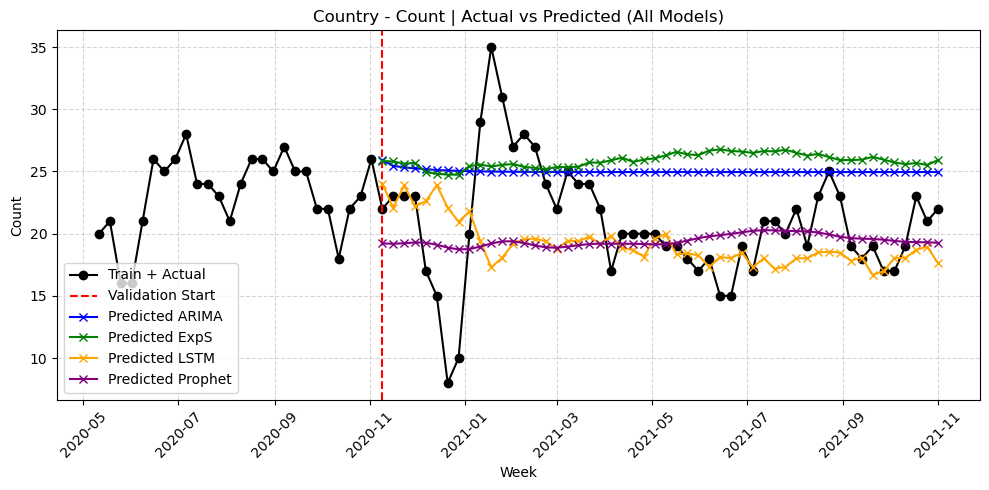

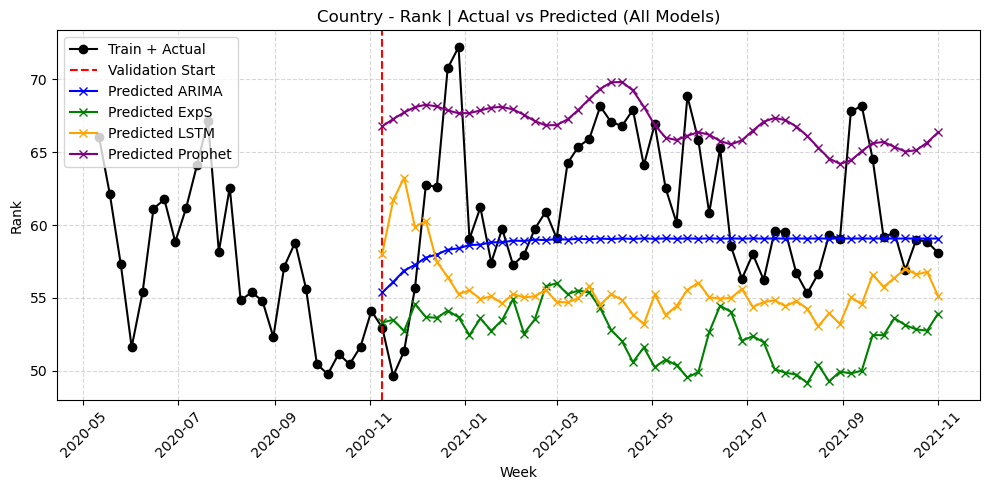

[DEBUG] Train rows: 3249, Valid rows: 52


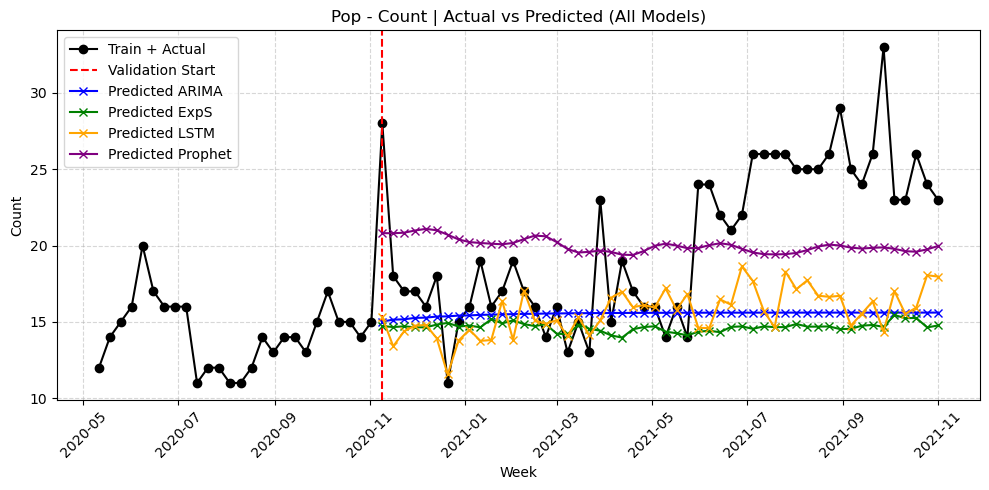

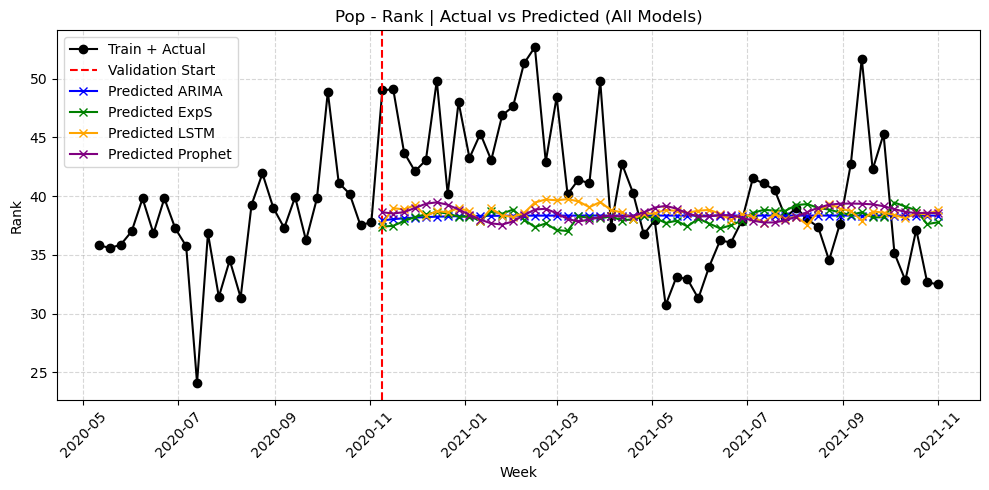

[DEBUG] Train rows: 3165, Valid rows: 52


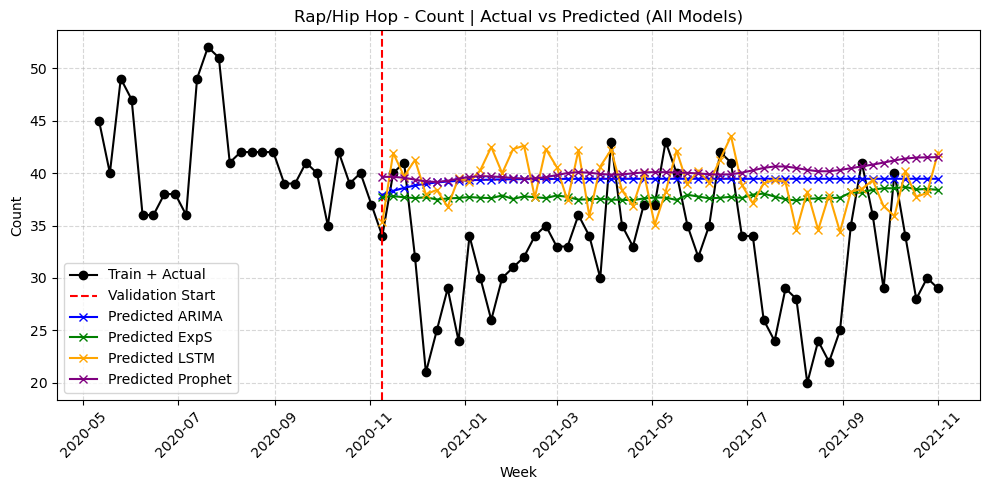

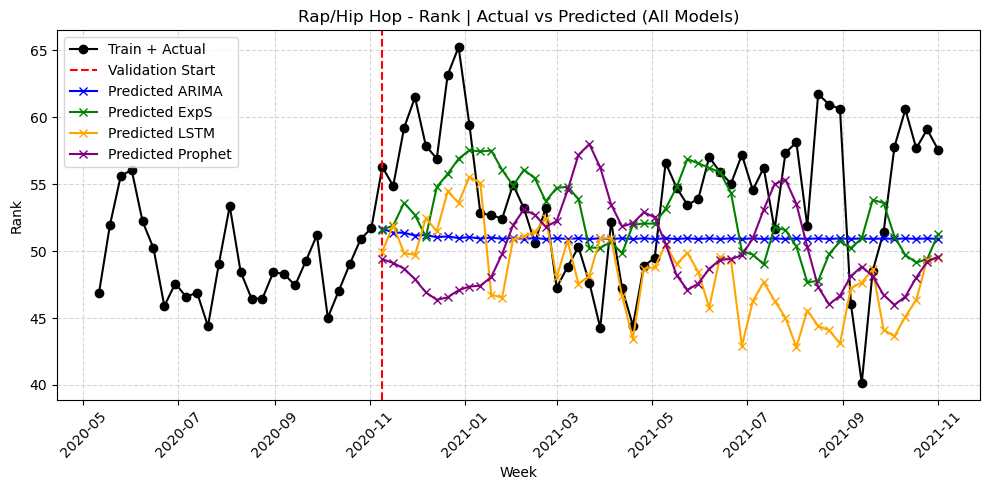

[DEBUG] Train rows: 3206, Valid rows: 52


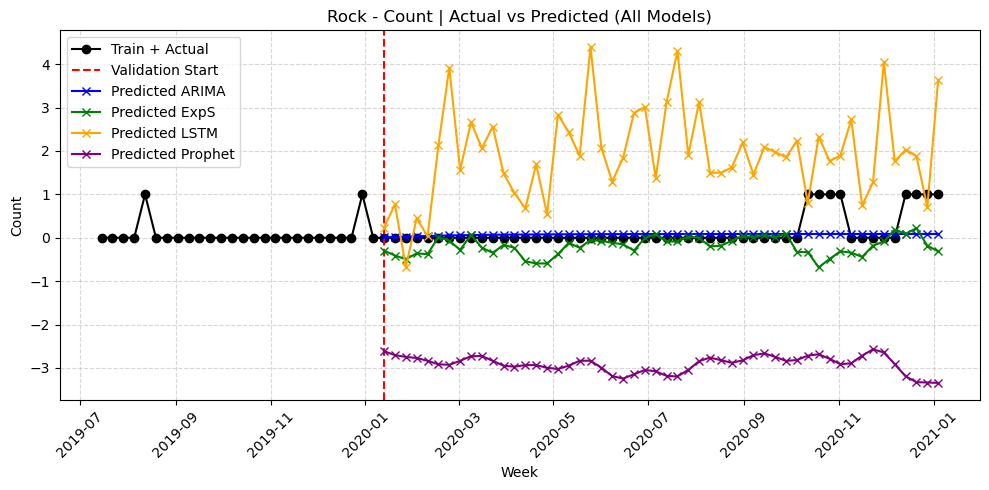

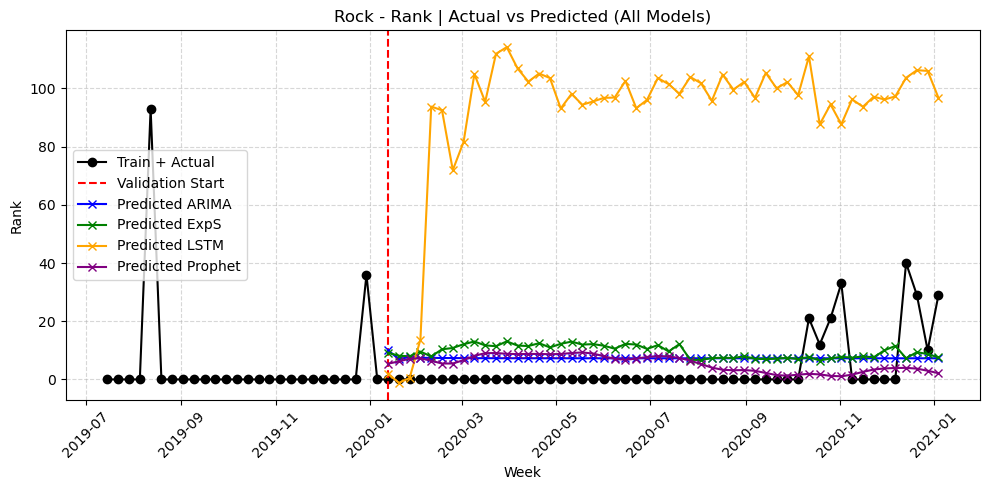

In [18]:
# === MAIN: Run validation and forecasting ===
# Update DATA_PATH above before running this cell.
forecast_weeks = 20
validation_weeks = 52
DATA_PATH = 'BIG_DATA2.csv'

if 'df' not in globals():
    try:
        df = load_dataset(DATA_PATH)
    except Exception as e:
        print('Could not load dataset automatically. Please set DATA_PATH and run load_dataset manually.')
        raise

grouped = build_genre_week_features(df)
grouped = grouped[grouped["genre"].isin(['Pop', 'Rap/Hip Hop', 'Country', 'Rock'])]
unique_genres = grouped['genre'].unique()

pred_csv = "prediction_evaluation.csv"
plot_dir = 'plots'
df = pd.read_csv(pred_csv, parse_dates=["week"])
genres = grouped["genre"].unique()

for genre in genres:
    genre_df = grouped[grouped["genre"]==genre]
    
    # Reindex and fill missing rows
    all_weeks = pd.date_range(
        start=genre_df["week"].min(),
        end=genre_df["week"].max(),
        freq="W-MON"
    )
    genre_df = genre_df.set_index("week").reindex(all_weeks)
    genre_df["genre"] = genre
    genre_df = genre_df.fillna(0)
    genre_df = genre_df.reset_index().rename(columns={"index":"week"})
    feature_list = genre_df.columns.difference(['week', 'genre']).tolist()
    
    genre_df = add_rolling_features(genre_df, feature_list, [5])
    genre_df.to_csv("train_debug.csv", index=False)
    tr, va = train_valid_split(genre_df, valid_weeks=validation_weeks)

    sub = df[df["genre"] == genre].sort_values("week")

    # Extract actual validation series as pandas Series
    ts_valid_count = pd.Series(sub["actual_count"].values, index=sub["week"])
    ts_valid_rank  = pd.Series(sub["actual_rank"].values, index=sub["week"])

    # Extract all models automatically
    model_names = sorted([col.replace("_pred_count", "")
                          for col in sub.columns
                          if col.endswith("_pred_count")])

    # Build prediction dictionaries for Count and Rank
    preds_count_dict = {
        model: sub[f"{model}_pred_count"].values
        for model in model_names
    }
    preds_rank_dict = {
        model: sub[f"{model}_pred_rank"].values
        for model in model_names
    }

    steps = len(sub)

    # Plot
    plot_pred_vs_actual_all_models(ts_valid_count, series_from_weeks(tr["week"].values, tr["count"].values), genre, preds_count_dict, target="Count", steps=steps, outpath=None)
    plot_pred_vs_actual_all_models(ts_valid_rank, series_from_weeks(tr["week"].values, tr["avg_rank"].values), genre, preds_rank_dict, target="Rank", steps=steps, outpath=None)


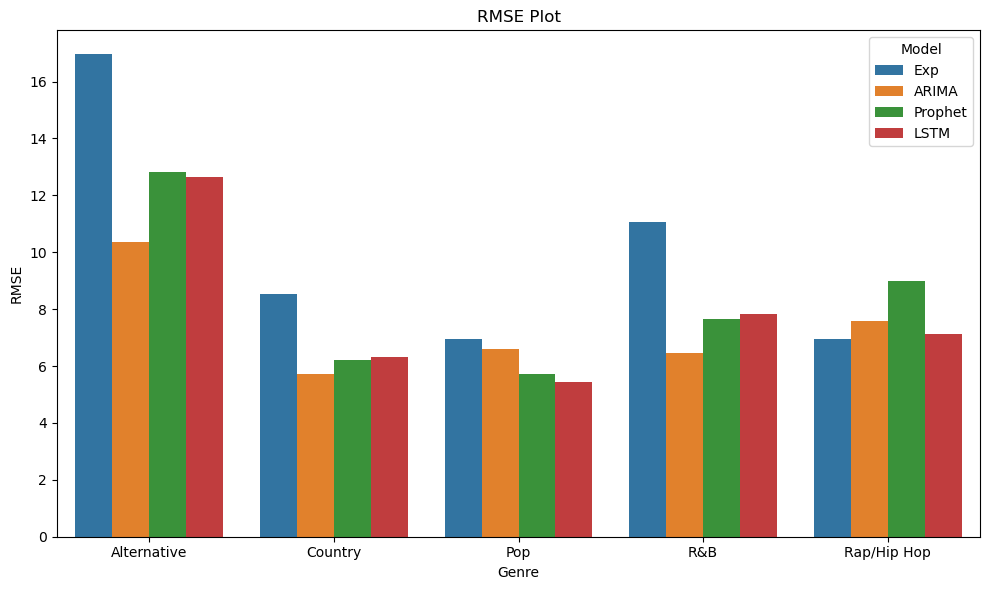

In [19]:
metrics_df = pd.read_csv('data/evaluate_summary.csv')

columns = ['genre']+[col for col in metrics_df.columns if 'RMSE' in col]
metrics_df = metrics_df[columns]

models = ["Exp", "ARIMA", "Prophet", "LSTM"]
# Prepare Count RMSE
count_rmse = metrics_df[["genre"] + [m+"_RMSE_Count" for m in models]].melt(id_vars="genre", 
                                                                         var_name="Model", 
                                                                         value_name="RMSE")
count_rmse["Target"] = "Count"
count_rmse["Model"] = count_rmse["Model"].str.replace("_RMSE_Count","")

# Prepare Rank RMSE
rank_rmse = metrics_df[["genre"] + [m+"_RMSE_Rank" for m in models]].melt(id_vars="genre", 
                                                                         var_name="Model", 
                                                                         value_name="RMSE")
rank_rmse["Target"] = "Rank"
rank_rmse["Model"] = rank_rmse["Model"].str.replace("_RMSE_Rank","")

# Combine
rmse_long = pd.concat([count_rmse, rank_rmse], ignore_index=True)

plt.figure(figsize=(10,6))
sns.barplot(data=rmse_long, x="genre", y="RMSE", hue="Model", ci=None)
plt.title("RMSE Plot")
plt.ylabel("RMSE")
plt.xlabel("Genre")
plt.legend(title="Model")
plt.tight_layout()
plt.savefig('plots/model_rmse_plot.png')
plt.show()

[DEBUG] 
--- Top 5 Genres by Count ---

Top 5 by ExponentialSmoothing_Count
      Genre  ExponentialSmoothing_Count
Rap/Hip Hop                   28.925998
        Pop                   22.682156
    Country                   22.074085
        R&B                    9.653149
Alternative                    5.778262

Top 5 by ARIMA_Count
      Genre  ARIMA_Count
Rap/Hip Hop    30.701323
        Pop    21.024294
    Country    20.723431
        R&B     7.307323
Alternative     5.925608

Top 5 by Prophet_Count
      Genre  Prophet_Count
Rap/Hip Hop      40.177522
    Country      19.210734
        Pop      18.277684
Alternative       8.011702
        R&B       4.428202

Top 5 by LSTM_Count
      Genre  LSTM_Count
        Pop   28.657906
    Country   16.893244
Rap/Hip Hop   14.606909
Alternative    6.055942
        R&B    5.440816
[DEBUG] 
--- Top 5 Genres by Average Rank ---

Top 5 by ExponentialSmoothing_Rank
      Genre  ExponentialSmoothing_Rank
    Country                  58.475469
R

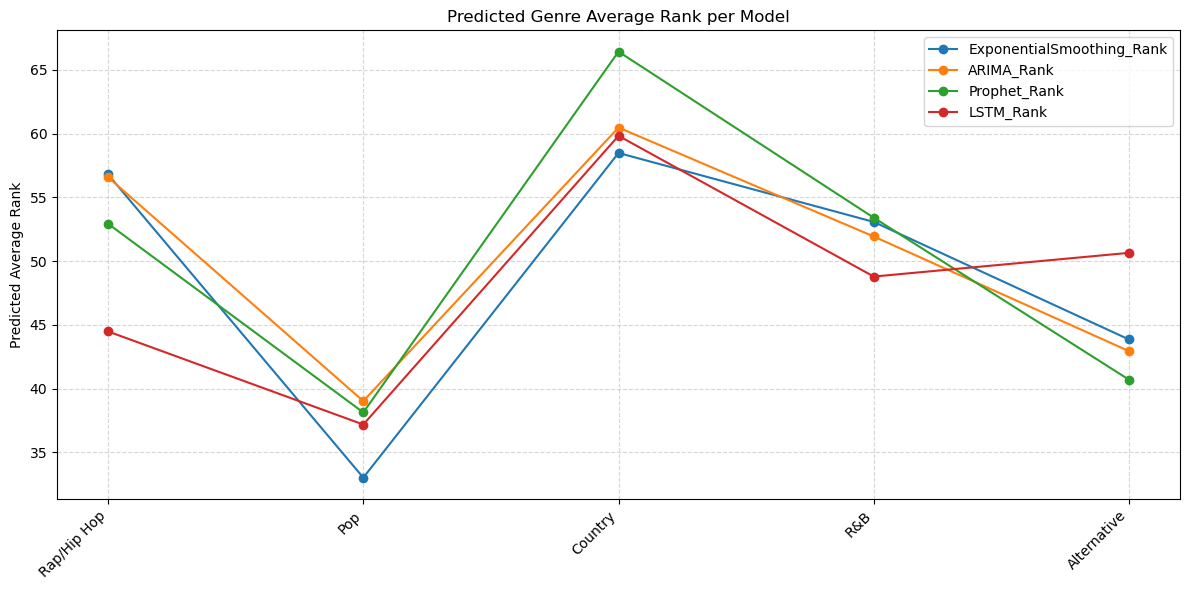

[DEBUG] Saved trend plots (count & rank) to plots/trend_per_model_weekly_count.png and plots/trend_per_model_weekly_rank.png


In [20]:
pred_final = pd.read_csv('data/final_forecasts_summary.csv')

log("\n--- Top 5 Genres by Count ---")
top5_count = top5_per_model(pred_final, target="Count")
for model, df_top5 in top5_count.items():
    print(f"\nTop 5 by {model}")
    print(df_top5.to_string(index=False))

log("\n--- Top 5 Genres by Average Rank ---")
top5_rank = top5_per_model(pred_final, target="Rank")
for model, df_top5 in top5_rank.items():
    print(f"\nTop 5 by {model}")
    print(df_top5.to_string(index=False))

plot_trend_per_model(pred_final, outpath=f"plots/trend_per_model_weekly.png")
